# Set - Up

In [8]:
import tensorflow as tf

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [20]:
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!cp -r "/content/drive/MyDrive/Face Mask Dataset" /content/

In [30]:
base_path = "/content/Face Mask Dataset"
train_dir = base_path + "/Train"
val_dir   = base_path + "/Validation"
test_dir  = base_path + "/Test"

In [3]:
import os

In [31]:
print(os.listdir("/content/Face Mask Dataset"))

['Validation', 'Test', 'Train']


In [32]:
print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['WithMask', 'WithoutMask']
Validation folders: ['WithMask', 'WithoutMask']
Test folders: ['WithMask', 'WithoutMask']


# Data processing

In [33]:
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [34]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 10000 images belonging to 2 classes.


In [35]:
val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 800 images belonging to 2 classes.


In [36]:
test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 992 images belonging to 2 classes.


In [37]:
print("train data indices: ", train_data.class_indices)
print("test data indices: ", test_data.class_indices)
print("valid data indices: ", val_data.class_indices)

train data indices:  {'WithMask': 0, 'WithoutMask': 1}
test data indices:  {'WithMask': 0, 'WithoutMask': 1}
valid data indices:  {'WithMask': 0, 'WithoutMask': 1}


In [38]:
images, labels = next(train_data)
print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 2)


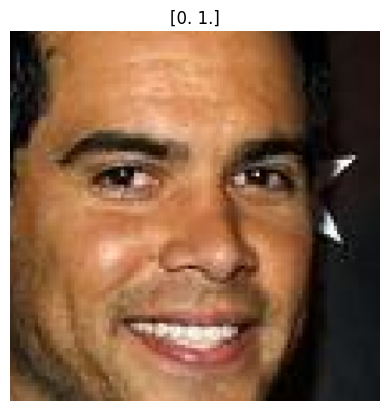

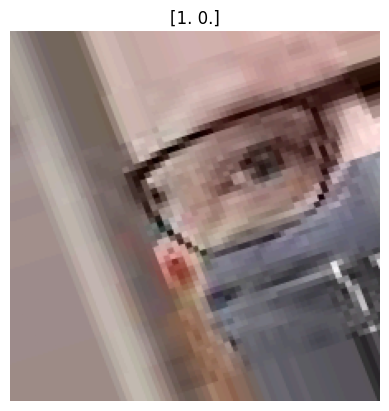

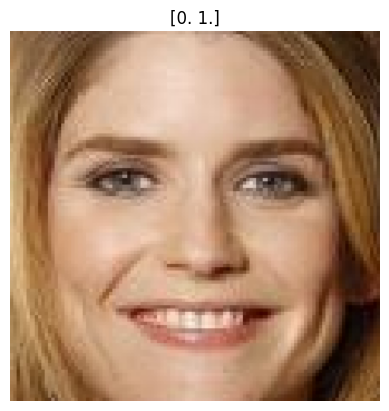

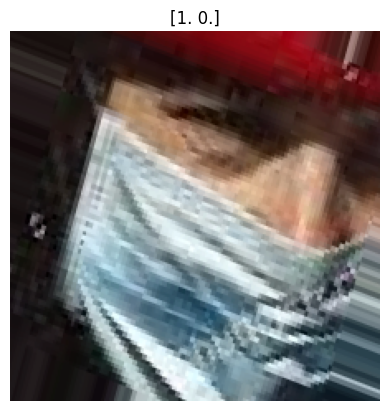

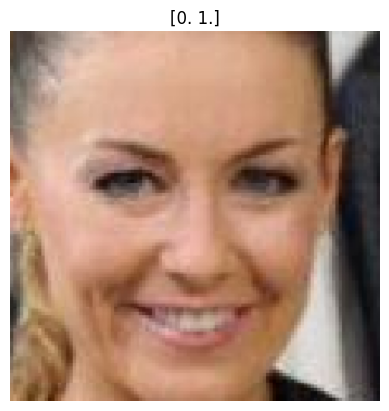

In [39]:
for i in range(5):
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')
    plt.show()

# Model Building

In [23]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
for layer in base_model.layers:
    layer.trainable = False

In [40]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,286,530 (39.24 MB)

 Trainable params: 8,028,546 (30.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=100,
    validation_steps=50
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.9675 - loss: 0.1190 - val_accuracy: 0.9950 - val_loss: 0.0240
Epoch 2/3
  3/100 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9809 - loss: 0.1964

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.9878 - loss: 0.0446 - val_accuracy: 0.9962 - val_loss: 0.0169
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9903 - loss: 0.0278 - val_accuracy: 0.9962 - val_loss: 0.0053


In [44]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9938 - loss: 0.0205 - val_accuracy: 0.9950 - val_loss: 0.0220
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9958 - loss: 0.0121 - val_accuracy: 0.9950 - val_loss: 0.0131
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.9981 - loss: 0.0052 - val_accuracy: 0.9962 - val_loss: 0.0094
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9962 - val_loss: 0.0142
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.9973 - loss: 0.0100 - val_accuracy: 0.9962 - val_loss: 0.0093


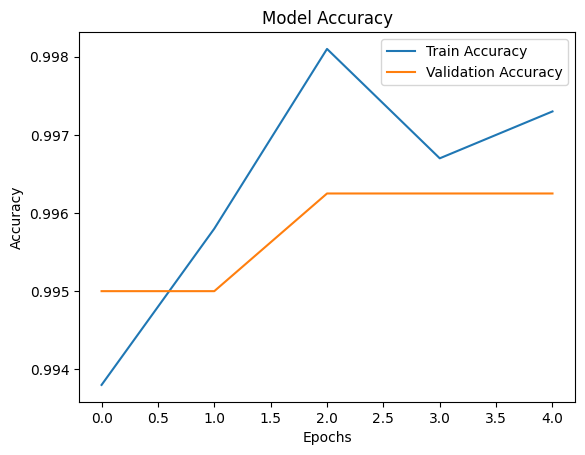

In [47]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.savefig("accuracy.png")
plt.show()

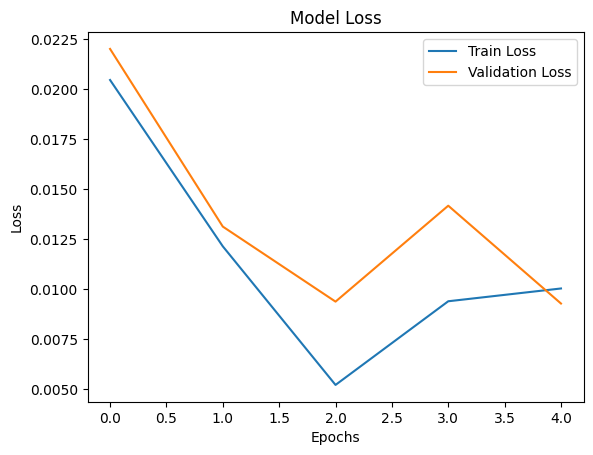

In [48]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train Loss', 'Validation Loss'])
plt.savefig("loss.png")
plt.show()

In [49]:
model.save("mask_detector.h5")

In [50]:
model.save("mask_detector.keras")